In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
spotify_df = pd.read_csv("../data/Cleaned_Spotify_2024_Global_Streaming_Data.csv")
spotify_df.head()
 


,Country,Artist,Album,Genre,Release Year,Monthly Listeners (Millions),Total Streams (Millions),Total Hours Streamed (Millions),Avg Stream Duration (Min),Platform Type,Streams Last 30 Days (Millions),Skip Rate (%)
0,Germany,Taylor Swift,1989 (Taylor's Version),K-pop,2020,23.10,3695.53,14240.35,4.28,Free,118.51,2.24
1,Brazil,The Weeknd,After Hours,R&B,2023,60.60,2828.16,11120.44,3.90,Premium,44.87,23.98
2,United States,Post Malone,Austin,Reggaeton,2019,42.84,1425.46,4177.49,4.03,Free,19.46,4.77
3,Italy,Ed Sheeran,Autumn Variations,K-pop,2019,73.24,2704.33,12024.08,3.26,Premium,166.05,25.12
4,Italy,Ed Sheeran,Autumn Variations,R&B,2019,7.89,3323.25,13446.32,4.47,Free,173.43,15.82


In [22]:
#group by Genre and calculate average total streams

avg_streams = spotify_df.groupby("Genre")['Total Streams (Millions)'].mean().sort_values(ascending=False)
avg_streams

Genre
R&B          2779.311707
K-pop        2760.691667
Classical    2739.955417
Pop          2686.797500
Indie        2661.669400
Rock         2558.947069
EDM          2466.699804
Jazz         2408.460000
Reggaeton    2404.313636
Hip Hop      2284.867551
Name: Total Streams (Millions), dtype: float64

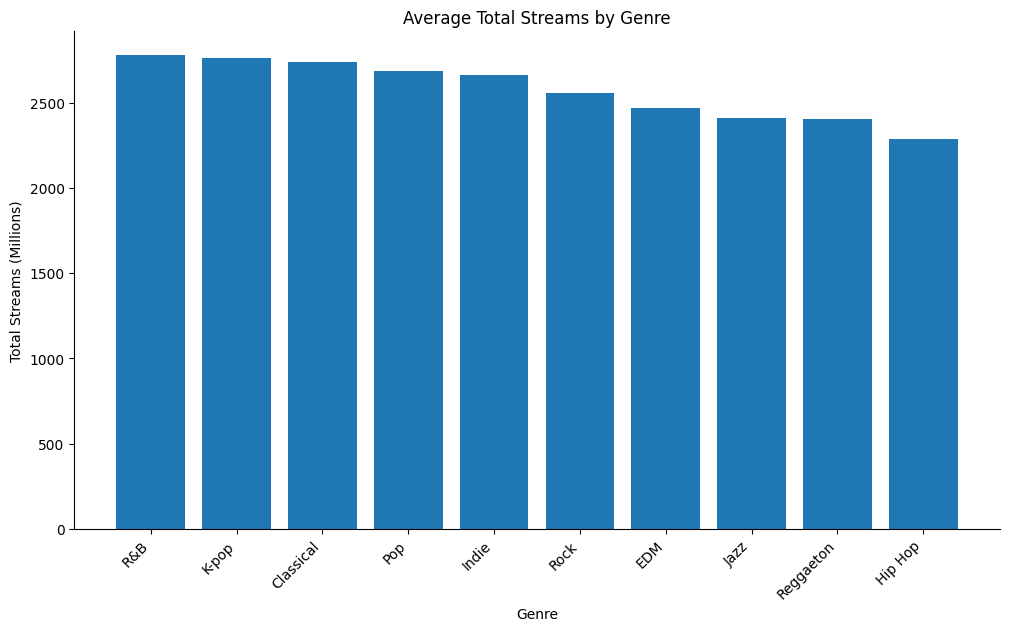

In [23]:
plt.figure(figsize=(10,6))
plt.bar(avg_streams.index,avg_streams.values)
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xlabel('Genre')

plt.ylabel('Total Streams (Millions)')
plt.title("Average Total Streams by Genre")
plt.show()

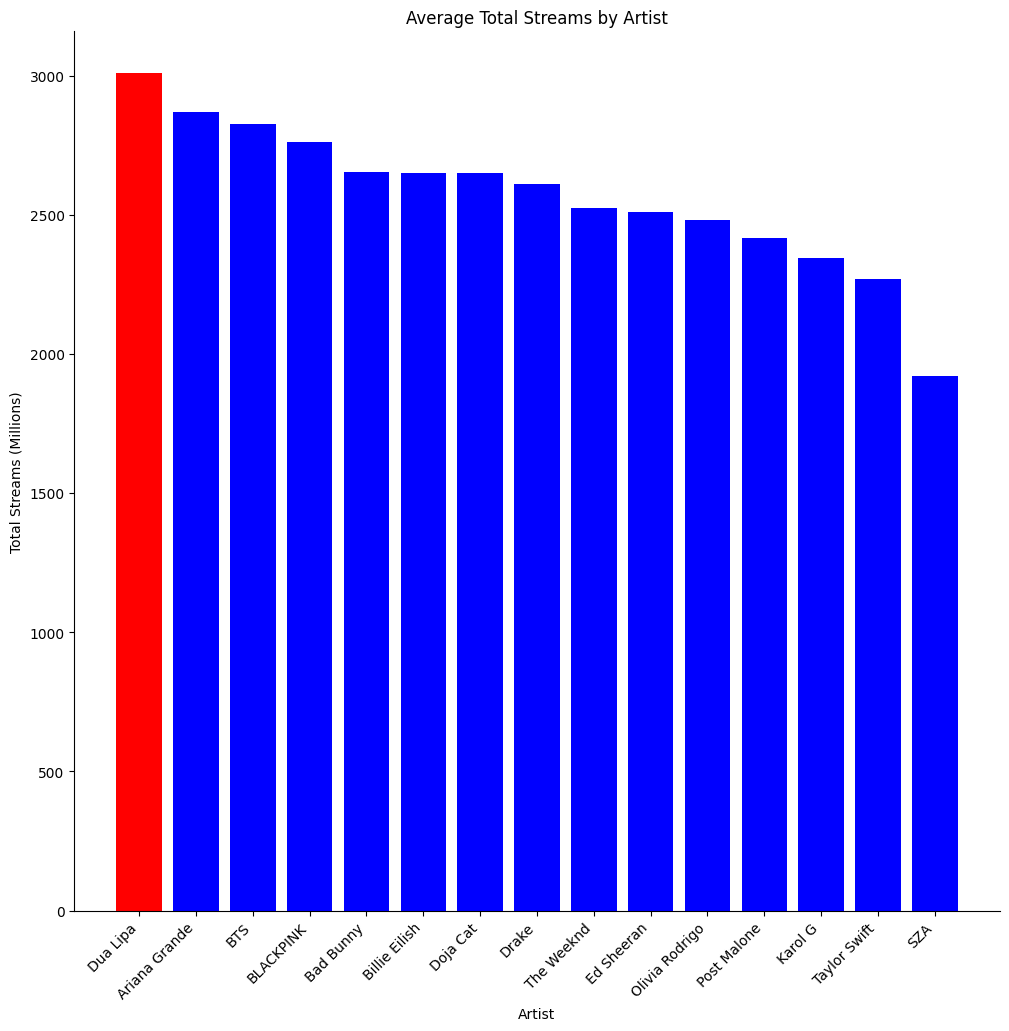

In [55]:

avg_artist_streams = spotify_df.groupby('Artist')["Total Streams (Millions)"].mean().sort_values(ascending=False)
colors = ["blue"]*len(avg_artist_streams)

max_index = avg_artist_streams.idxmax()

highlight_position = avg_artist_streams.index.get_loc(max_index)

colors[highlight_position]= "red"

plt.figure(figsize=(10,10))
plt.bar(avg_artist_streams.index ,avg_artist_streams.values, color = colors, width=0.8)
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Artist')
plt.ylabel('Total Streams (Millions)')
plt.title("Average Total Streams by Artist")

plt.show()

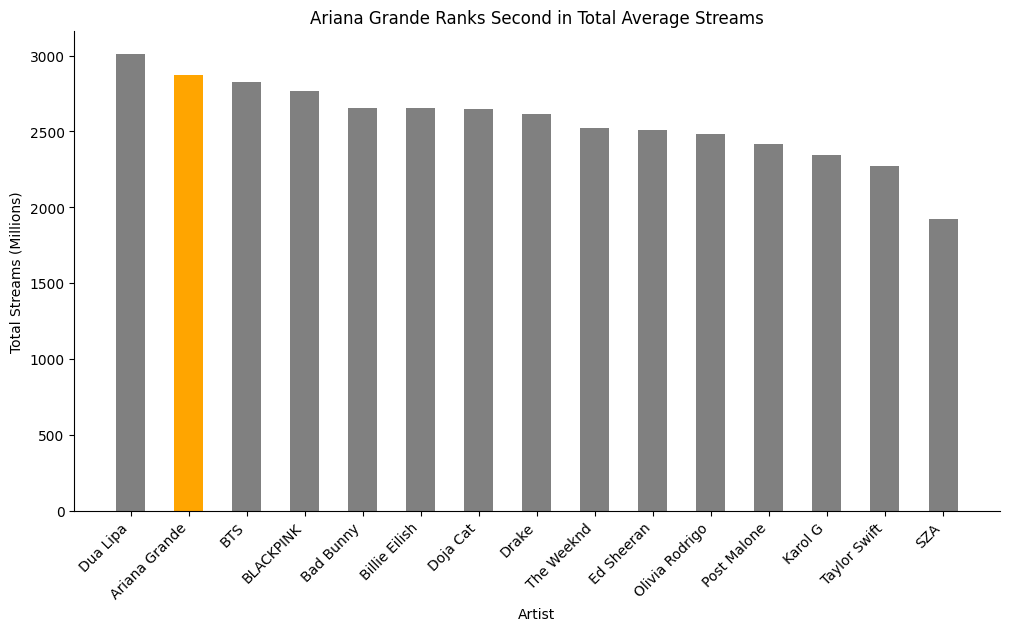

In [56]:

avg_artist_streams = spotify_df.groupby('Artist')["Total Streams (Millions)"].mean().sort_values(ascending=False)


special_artist = "Ariana Grande"
colors= ["Orange" if artist == special_artist else "gray" for artist in avg_artist_streams.index]
plt.figure(figsize=(10,6))
plt.bar(avg_artist_streams.index ,avg_artist_streams.values, color = colors, width=0.5)
plt.xticks(rotation=45,ha="right")
plt.tight_layout()
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Artist')
plt.ylabel('Total Streams (Millions)')
plt.title("Ariana Grande Ranks Second in Total Average Streams")

plt.show()

In [59]:
yearly_avg = spotify_df.groupby("Release Year") ["Total Streams (Millions)"].mean().round(2)
yearly_avg

Release Year
2018    2611.26
2019    2516.45
2020    2569.62
2021    2763.21
2022    2367.99
2023    2817.97
Name: Total Streams (Millions), dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

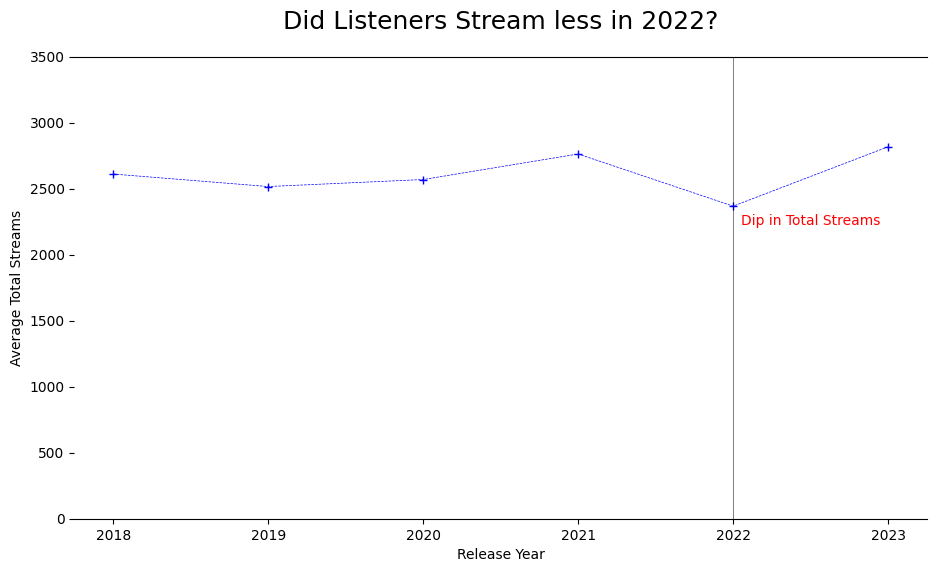

In [86]:
plt.figure(figsize=(11,6))
plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker = "+",
    linestyle ="--", 
    color = "blue",
    linewidth = 0.5
)

plt.xlabel("Release Year")
plt.ylabel("Average Total Streams")
plt.title("Did Listeners Stream less in 2022?", fontsize =18 ,pad =20)

ax=plt.gca()
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.axvline (
    2022,
    color = "black",
    linewidth = 0.5,
    alpha = 0.7
           )
ax.text(
    2022+0.05,
    2225 ,
    "Dip in Total Streams",
    color = "Red",
    fontsize= 10
)
plt.ylim(0, 3500)


plt.show

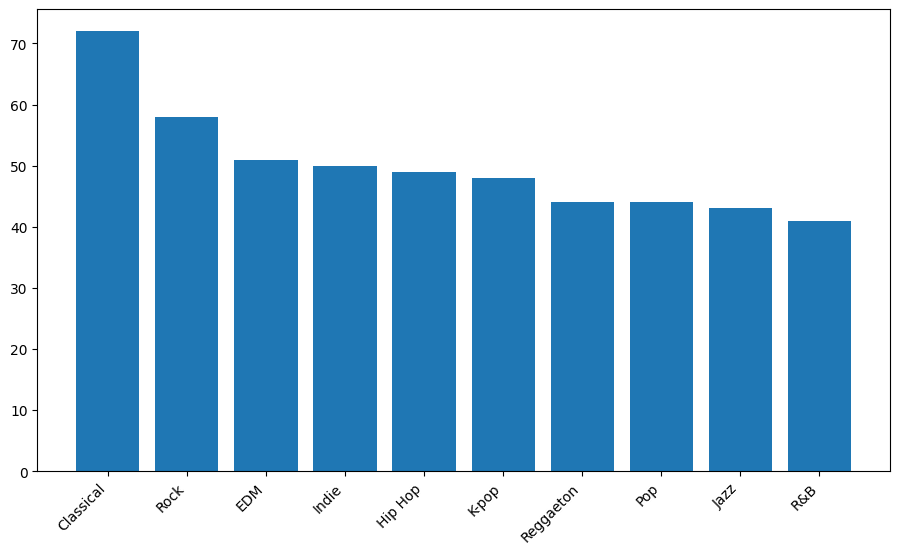

In [89]:
genre_counts= spotify_df['Genre'].value_counts().sort_values(ascending=False)
genre_counts

plt.figure(figsize=(11,6))
plt.bar(genre_counts.index ,genre_counts.values)
plt.xticks(rotation=45, ha="right")
plt.show()